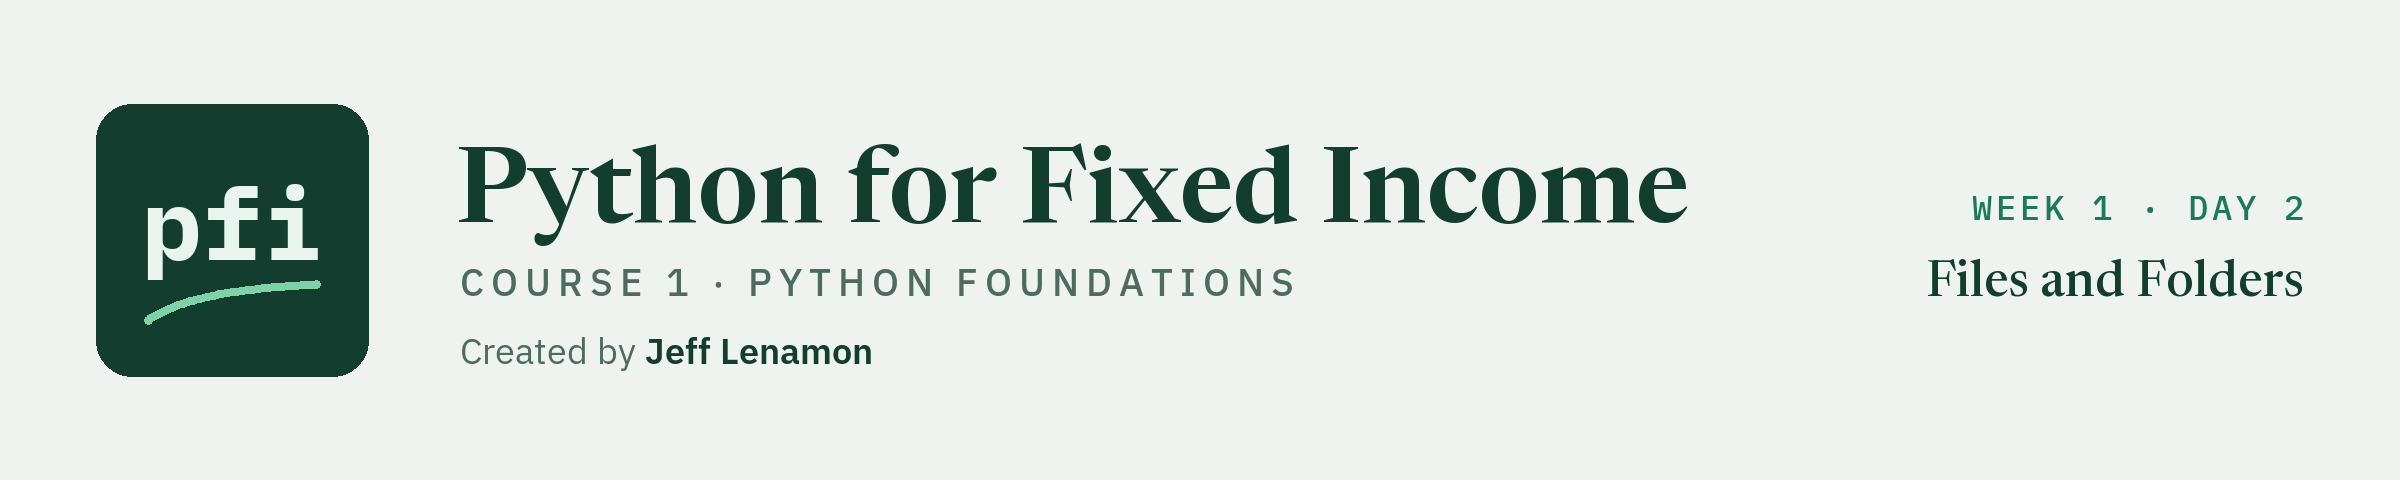

# Files and Folders

Week 1. Using Python to find, create, and organize the files a bond desk works with.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week1/day2/02_files_and_folders.ipynb)

Every morning the credit desk receives a holdings file showing what it owns. Those files pile up: one a day, every day. Someone has to keep them in the right folders, and someone has to open them.

Python can do both. In this notebook we use it to look around the computer, make folders, and write and read a holdings file. The four bonds are the ones from the last notebook, and the issuers are invented.

| Ticker | Coupon (%) | Maturity | Price | Face held |
| --- | --- | --- | --- | --- |
| QVNE | 5.25 | 2033 | 98.50 | 1,500,000 |
| DNMR | 6.125 | 2034 | 103.25 | 500,000 |
| PLWK | 4.75 | 2031 | 95.00 | 750,000 |
| HLVF | 7.50 | 2032 | 101.00 | 250,000 |

## 2.1 The os Module

Python comes with toolboxes called **modules**. A module is not loaded until we ask for it with `import`.

The `os` module talks to the operating system: Windows, macOS, or Linux. It is how Python works with files and folders.

In [1]:
# load the os module
import os

Q. Which operating system is this notebook running on?

In [2]:
# os.name holds a short code for the operating system
print(os.name)

nt


* `nt` means Windows. `posix` means macOS or Linux, which is what you will see in Google Colab.
* After `import os`, everything in the module is reached with `os.` followed by a name.

The notebook makes some folders and files as it goes. This cell removes any left over from an earlier run, so the notebook can be run again from the top.

In [3]:
# shutil is another module that comes with Python. rmtree removes a folder and everything in it.
import shutil

for folder in ['holdings', 'desk_holdings']:
    # ignore_errors=True means: do nothing if the folder is not there
    shutil.rmtree(folder, ignore_errors=True)

## 2.2 The Working Directory

A **directory** is another word for a folder. Python is always sitting in one folder, called the **working directory**. When we give it a file name with no folder in front, that is where it looks.

Q. Which folder is Python working in right now?

In [4]:
# getcwd stands for 'get current working directory'
os.getcwd()

* The answer is the full **path** to the folder: every folder from the top of the drive down to this one. Yours will be different from anyone else's, which is why no output is saved here.
* On Windows the folders in a path are separated by backslashes. Run on its own like this, Python shows the path in its code form, with each backslash doubled as `\\`. `print()` shows the text itself, with single backslashes. Section 2.4 explains the doubling.

Q. What is the name of just the last folder in that path?

In [5]:
# basename keeps only the last part of a path
print(os.path.basename(os.getcwd()))

day2


* For a notebook opened from the course repo on your own machine, the working directory is the folder the notebook sits in, here `day2`.
* In Google Colab the working directory is `/content`, a temporary folder on Google's machine. You will see `content` above, and the next cells will list `.config` and `sample_data` in place of the notebook. Anything written there is deleted when the Colab session ends.

## 2.3 The Contents of a Folder

Q. What files are in the working directory?

In [6]:
# '.' is shorthand for the current working directory
os.listdir('.')

['02_files_and_folders.ipynb']

* `listdir()` returns a **list** of names, which means everything from the last notebook works on it. Your list may show more files than this one.

Q. How many items are in the working directory?

In [7]:
# len() counts the items in a list
print(len(os.listdir('.')))

1


Q. Print each name on its own line.

In [8]:
for name in os.listdir('.'):
    print(name)

02_files_and_folders.ipynb


Q. Which of them are notebooks?

In [9]:
# endswith() checks how a string ends. Notebook files end in .ipynb
notebooks = [name for name in os.listdir('.') if name.endswith('.ipynb')]
print(notebooks)

['02_files_and_folders.ipynb']


## 2.4 Making and Renaming Folders

Q. The desk wants a folder to keep its daily holdings files in. Create a folder named 'holdings'.

In [10]:
# mkdir stands for 'make directory'
os.mkdir('holdings')

* Nothing is printed. Many commands that change something work quietly. Let's check that it worked.

In [11]:
# exists() returns True if the folder or file is there
print(os.path.exists('holdings'))

True


What happens if we try to create the same folder again?

In [12]:
os.mkdir('holdings')

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'holdings'

* A `FileExistsError`. Python refuses because the folder already exists. Nothing inside it is touched.

Q. Create the folder only if it does not already exist.

In [13]:
# check first, then create. 'not' flips True to False, so this reads: if the folder does not exist
if not os.path.exists('holdings'):
    os.mkdir('holdings')
    print('Folder created')
else:
    print('Folder already exists')

Folder already exists


Q. Another team already uses the name 'holdings'. Rename the folder to 'desk_holdings'.

In [14]:
# rename takes the old name, then the new name
os.rename('holdings', 'desk_holdings')
print(os.path.exists('holdings'))
print(os.path.exists('desk_holdings'))

False
True


* The old name is gone and the new one exists.

The desk files its holdings by date, one folder per day inside 'desk_holdings'. To point at a folder inside another folder we have to build a path.

Q. Build the path to a folder named '2026-10-02' inside 'desk_holdings'.

In [15]:
# join glues the parts of a path together with the right separator
day_folder = os.path.join('desk_holdings', '2026-10-02')
print(day_folder)

desk_holdings\2026-10-02


* On Windows the separator is a backslash. On macOS, Linux, and Colab it is a forward slash. `os.path.join()` picks the right one, so the same code runs everywhere.

Why not just type the backslash ourselves? Let's try a path to a folder named 'new'.

In [16]:
print('desk_holdings\new')

desk_holdings
ew


* The path broke across two lines. Inside a string, a backslash followed by certain letters has a special meaning, and `\n` means 'start a new line'. This is the reason Python showed the backslashes doubled in section 2.2: `\\` means one real backslash.
* Typing Windows paths by hand is a classic source of bugs. Use `os.path.join()` and the problem never comes up.

Q. Create the dated folder.

In [17]:
os.mkdir(day_folder)
print(os.listdir('desk_holdings'))

['2026-10-02']


## 2.5 Creating and Editing a File

Now the desk needs the holdings file itself. We will write it as a **CSV** file: plain text, one bond per line, with commas between the values. Excel opens CSV files directly.

Q. Build the path to a file named 'holdings.csv' inside the dated folder.

In [18]:
file_path = os.path.join(day_folder, 'holdings.csv')
print(file_path)

desk_holdings\2026-10-02\holdings.csv


Q. Create the file and write a header line and the first bond into it.

In [19]:
# open the file for writing. 'w' stands for write
file = open(file_path, 'w', encoding='utf-8')
# write the header line. \n ends the line
file.write('Ticker,Coupon,Maturity,Price,Face\n')
# write the first bond
file.write('QVNE,5.25,2033,98.5,1500000\n')
# close the file so that the lines are saved
file.close()

* `open()` with `'w'` creates the file if it does not exist. If it does exist, `'w'` wipes it and starts again.
* Always say `encoding='utf-8'`. It sets how characters are stored in the file. Without it, Windows uses an older default, and a file with an accented letter or a currency sign can read differently on another machine.
* Each `write()` adds text exactly as given. We end each line with `\n` ourselves.
* `close()` matters. Until the file is closed, the text may not be saved to disk.

Q. Read the file back to check what was written.

In [20]:
# open the file for reading. 'r' stands for read
file = open(file_path, 'r', encoding='utf-8')
# read() returns the whole file as one string
contents = file.read()
file.close()
print(contents)

Ticker,Coupon,Maturity,Price,Face
QVNE,5.25,2033,98.5,1500000



It is easy to forget `close()`. Python has a safer way to open a file: the `with` statement. The file is closed automatically when the indented block ends.

Q. Add the other three bonds to the file.

In [21]:
# 'a' stands for append: add to the end and keep what is already there
with open(file_path, 'a', encoding='utf-8') as file:
    file.write('DNMR,6.125,2034,103.25,500000\n')
    file.write('PLWK,4.75,2031,95.0,750000\n')
    file.write('HLVF,7.5,2032,101.0,250000\n')

In [22]:
# read the file again
with open(file_path, 'r', encoding='utf-8') as file:
    print(file.read())

Ticker,Coupon,Maturity,Price,Face
QVNE,5.25,2033,98.5,1500000
DNMR,6.125,2034,103.25,500000
PLWK,4.75,2031,95.0,750000
HLVF,7.5,2032,101.0,250000



* All four bonds are there, under the header. The three ways to open a file are `'r'` to read, `'w'` to write from scratch, and `'a'` to append.

**Excel side by side.** Open `holdings.csv` in Excel and it shows five rows and five columns, because Excel splits each line at the commas. That holds where Excel's list separator is a comma, as in US and UK regional settings. Where the regional list separator is a semicolon, Excel shows each line in a single column. A CSV file is the simplest way to pass a table between Python and Excel.

Reading the file as one long string is fine for looking at it. To calculate with it, we want it line by line.

Q. How many lines are in the file?

In [23]:
# readlines() returns a list with one string per line
with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

print(len(lines))
print(lines)

5
['Ticker,Coupon,Maturity,Price,Face\n', 'QVNE,5.25,2033,98.5,1500000\n', 'DNMR,6.125,2034,103.25,500000\n', 'PLWK,4.75,2031,95.0,750000\n', 'HLVF,7.5,2032,101.0,250000\n']


* Five lines: one header and four bonds. Each string still carries its `\n` at the end.

Q. Print the ticker and the face held of each bond.

In [24]:
# lines[1:] skips the header, which is the first item
for line in lines[1:]:
    # strip() removes the \n, and split(',') cuts the line at each comma
    values = line.strip().split(',')
    print(f'{values[0]} has face of {values[4]}')

QVNE has face of 1500000
DNMR has face of 500000
PLWK has face of 750000
HLVF has face of 250000


* `split(',')` turns one line into a list of its values. The ticker is at index 0 and the face is at index 4.
* Cutting at every comma works here because no value contains a comma. A value with a comma inside it, such as an issuer name, would be cut in two, and every later value would shift one place with no error. Section 2.6 shows this going wrong, and the tool that reads such a file correctly.

Q. What is the total face held in the file?

In [25]:
# start a running total at zero
total_face = 0
for line in lines[1:]:
    values = line.strip().split(',')
    # everything read from a file is a string, so convert the face to a number
    total_face = total_face + int(values[4])

print(f'The total face held is {total_face:,}')

The total face held is 3,000,000


* 3,000,000, which matches the total from the last notebook.
* Everything read from a file arrives as a string. It has to be converted with `int()` or `float()` before any arithmetic.

What happens if we forget to convert?

In [26]:
total_face = 0
for line in lines[1:]:
    values = line.strip().split(',')
    total_face = total_face + values[4]

TypeError: unsupported operand type(s) for +: 'int' and 'str'

* A `TypeError`. Python cannot add the string '1500000' to the number 0. The error is a reminder that the file gave us text.

## 2.6 The csv Module

Cutting a line at every comma has one weakness, and it is a quiet one. Suppose the file also carried the issuer's full name.

Q. One line of such a file reads `QVNE,"Quorvane Energy, Inc.",1500000`: a ticker, an issuer name, and a face amount. The name has a comma inside it, and the quotes around it are how a CSV file marks that. Split the line at the commas and count the pieces.

In [27]:
# one line with three values. The issuer name has a comma in it
line = 'QVNE,"Quorvane Energy, Inc.",1500000'
values = line.split(',')
print(values)
print(f'{len(values)} pieces')
# the face should be the third value, at index 2
print(f'Index 2 holds: {values[2]}')

['QVNE', '"Quorvane Energy', ' Inc."', '1500000']
4 pieces
Index 2 holds:  Inc."


* Three values came out as 4 pieces, with no error. The name was cut in two, and the face is no longer where the code expects it. Index 2 now holds the tail of the name.

Python comes with a module that knows the rules of CSV files, quotes included.

Q. Read the same line with the `csv` module.

In [28]:
# load the csv module, which comes with Python
import csv

# csv.reader takes lines of text and hands back each line as a list of values
# here it is given a list that holds our one line
for values in csv.reader([line]):
    print(values)
    print(f'{len(values)} values')
    print(f'Index 2 holds: {values[2]}')

['QVNE', 'Quorvane Energy, Inc.', '1500000']
3 values
Index 2 holds: 1500000


* 3 values. The reader kept the comma inside the quoted name, removed the quotes, and left the face at index 2.

**Excel side by side.** Excel follows the same rule. Save that line in a CSV file and open it in Excel, and `Quorvane Energy, Inc.` sits in one cell, with the face in the third column.

Q. Read the desk's holdings file with `csv.reader`. How many rows does it have, and what do the first two look like?

In [29]:
# newline='' leaves the line endings to the csv module, which is how its documentation says to open a file
with open(file_path, 'r', encoding='utf-8', newline='') as file:
    # list() collects every row the reader produces
    rows = list(csv.reader(file))

print(len(rows))
print(rows[0])
print(rows[1])

5
['Ticker', 'Coupon', 'Maturity', 'Price', 'Face']
['QVNE', '5.25', '2033', '98.5', '1500000']


* 5 rows, each one already split into a list, with no `\n` left on the end. The values are still strings.

Picking a value by its position, such as index 4 for the face, breaks if a column is ever added or moved. `csv.DictReader` uses the header line to give each value a name.

Q. Use `csv.DictReader` to total the face held.

In [30]:
total_face = 0
with open(file_path, 'r', encoding='utf-8', newline='') as file:
    # DictReader reads the header line first, then hands back each bond as a dictionary
    for row in csv.DictReader(file):
        # look the face up by its column name, and convert it from text to a number
        total_face = total_face + int(row['Face'])

print(f'The total face held is {total_face:,}')

The total face held is 3,000,000


* 3,000,000 again. `row['Face']` says what is being read, and it keeps working if the columns change order.
* For a real file, use the `csv` module or, from next week, pandas. Splitting at the commas by hand is a way to see what a CSV file is, and not a safe way to read one.

## 2.7 Paths With pathlib

The `os` functions treat a path as a plain string. Python has a second, newer toolbox called `pathlib`, in which a path is an object with its own attributes and methods. Both are in everyday use, so it pays to be able to read both.

Q. Build the path to the holdings file again, this time with `pathlib`.

In [31]:
# Path is the one name we need from the pathlib module
from pathlib import Path

# the / operator joins the parts of a path, as os.path.join() does
holdings_path = Path('desk_holdings') / '2026-10-02' / 'holdings.csv'
print(holdings_path)

desk_holdings\2026-10-02\holdings.csv


* The same path that `os.path.join()` built in section 2.5, with the separator chosen for us: a backslash on Windows, a forward slash on macOS, Linux, and Colab.
* `from pathlib import Path` loads one name from a module, so we can write `Path` on its own.

Q. Does the file exist? What is its name, and which folder is it in?

In [32]:
# exists() is a method of the path
print(holdings_path.exists())
# name is the last part of the path
print(holdings_path.name)
# parent is the folder the file sits in. It is a path too, so it has a name of its own
print(holdings_path.parent)
print(holdings_path.parent.name)

True
holdings.csv
desk_holdings\2026-10-02
2026-10-02


* The file exists, its name is `holdings.csv`, and it sits in the folder `2026-10-02`. The path carries these answers itself, with no function to wrap around it.

Q. List the CSV files in the dated folder.

In [33]:
# glob() finds everything in a folder whose name matches a pattern. The * stands for any text
csv_names = [path.name for path in holdings_path.parent.glob('*.csv')]
print(csv_names)

['holdings.csv']


* One file matches `*.csv`. `glob()` does in one step what took `os.listdir()` and `endswith()` in section 2.3.

| Job | With os | With pathlib |
| --- | --- | --- |
| Join the parts of a path | `os.path.join('desk_holdings', '2026-10-02')` | `Path('desk_holdings') / '2026-10-02'` |
| Check that it exists | `os.path.exists(path)` | `path.exists()` |
| Take the last part | `os.path.basename(path)` | `path.name` |
| Find the files that match | `os.listdir()` with `endswith()` | `path.glob('*.csv')` |

A `Path` can be handed to `open()`, and to pandas from next week, wherever a path written as a string is accepted. This course writes its data paths as plain strings and uses `os` in most places, so you will see both styles.

**Excel side by side.** The `*` is the wildcard Excel uses too. With file names in A1:A10, `=COUNTIF(A1:A10,"*.csv")` counts the names that end in .csv.

## 2.8 Cleaning Up

Q. The desk finds out the file was saved under the wrong date. It belongs to October 3. Rename the dated folder.

In [34]:
# build the new path, then rename
new_day_folder = os.path.join('desk_holdings', '2026-10-03')
os.rename(day_folder, new_day_folder)
print(os.listdir('desk_holdings'))

['2026-10-03']


In [35]:
# the file moved with its folder
print(os.listdir(new_day_folder))

['holdings.csv']


Q. Delete the file.

In [36]:
# remove deletes a file. There is no recycle bin, so be sure before running it.
os.remove(os.path.join(new_day_folder, 'holdings.csv'))
print(os.listdir(new_day_folder))

[]


Q. Delete the two folders.

In [37]:
# rmdir removes a folder, but only if it is empty
os.rmdir(new_day_folder)
os.rmdir('desk_holdings')
print(os.path.exists('desk_holdings'))

False


* `rmdir()` refuses to remove a folder that still has something in it. That is a safety feature. The inner folder had to go first.
* The working directory is back to how we found it.

## Exercises

A second desk records its trades. Today it bought three bonds. The issuers are invented.

| Ticker | Face bought | Price |
| --- | --- | --- |
| TRNW | 2,000,000 | 96.25 |
| OSMC | 1,250,000 | 100.00 |
| CLDB | 500,000 | 104.50 |

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next two cells first. The first defines `check`, which marks your answers. The second removes anything left over from an earlier attempt.

In [38]:
def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
    elif answer == expected:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)

In [39]:
import os
import shutil

# remove anything left over from an earlier attempt
for folder in ['blotter', 'trade_blotter']:
    shutil.rmtree(folder, ignore_errors=True)
if os.path.exists('ai_holdings.csv'):
    os.remove('ai_holdings.csv')

### Exercise 1

Q. Create a folder named 'blotter'. Then store whether it exists in **ex1_exists**.

In [40]:
ex1_exists = ...

In [41]:
check('Exercise 1', ex1_exists, True)

Exercise 1: not attempted yet


### Exercise 2

Q. Write a file named 'trades.csv' inside the 'blotter' folder. It should have the header line `Ticker,Face,Price` and one line for each of the three trades. Then read it back and store the number of lines in **ex2_line_count**.

In [42]:
ex2_line_count = ...

In [43]:
check('Exercise 2', ex2_line_count, 4)

Exercise 2: not attempted yet


### Exercise 3

Q. Read 'trades.csv' and work out the total cost of the three trades. The cost of a trade is face times price divided by 100. That is the cost at the clean price, with accrued interest left out. Store the answer in **ex3_total_cost**.

In [44]:
ex3_total_cost = ...

In [45]:
check('Exercise 3', ex3_total_cost, 3697500.0)

Exercise 3: not attempted yet


### Exercise 4

Q. Rename the 'blotter' folder to 'trade_blotter'. Then store the list of files inside it in **ex4_files**.

In [46]:
ex4_files = ...

In [47]:
check('Exercise 4', ex4_files, ['trades.csv'])

Exercise 4: not attempted yet


### Exercise 5

Q. Use `pathlib` to build the path to 'trades.csv' inside the 'trade_blotter' folder from Exercise 4. Store whether the file exists in **ex5_exists**, and the name of the folder it sits in in **ex5_folder**.

In [48]:
from pathlib import Path

ex5_exists = ...
ex5_folder = ...

In [49]:
check('Exercise 5 exists', ex5_exists, True)
check('Exercise 5 folder', ex5_folder, 'trade_blotter')

Exercise 5 exists: not attempted yet
Exercise 5 folder: not attempted yet


### Exercise 6

Q. Read 'trades.csv' in the 'trade_blotter' folder with `csv.DictReader` and total the Face column. Store the total in **ex6_total_face**.

In [50]:
import csv

ex6_total_face = ...

In [51]:
check('Exercise 6', ex6_total_face, 3750000)

Exercise 6: not attempted yet


### Exercise 7: AI check

You ask an AI assistant for code that creates a small holdings file and then adds one more bond to it. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Read the code before you run it. A header, three bonds, and one more bond: how many lines should the file have? Then run it.

In [52]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# create the file with a header and three bonds
with open('ai_holdings.csv', 'w', encoding='utf-8') as file:
    file.write('Ticker,Face\n')
    file.write('TRNW,2000000\n')
    file.write('OSMC,1250000\n')
    file.write('CLDB,500000\n')

# add one more bond to the file
with open('ai_holdings.csv', 'w', encoding='utf-8') as file:
    file.write('QVNE,1500000\n')

# count the lines in the file
with open('ai_holdings.csv', 'r', encoding='utf-8') as file:
    print(f'Lines in the file: {len(file.readlines())}')

Lines in the file: 1


Q. Find the bug. Then fix the code so the file ends up with every line it should have, and store the number of lines in **ex7_line_count**.

In [53]:
ex7_line_count = ...

In [54]:
check('Exercise 7', ex7_line_count, 5)

Exercise 7: not attempted yet


When you are finished, run this cell to remove the folders and files the exercises created.

In [55]:
for folder in ['blotter', 'trade_blotter']:
    shutil.rmtree(folder, ignore_errors=True)
if os.path.exists('ai_holdings.csv'):
    os.remove('ai_holdings.csv')